# 05 — Async CTRS-R Evaluation: Base vs. Fine-Tuned Qwen3.5

Same evaluation as 04, but with **concurrent API calls** for massive speedup.

**Simulation phase:** All 112 vignettes progress in lockstep — each round does
sequential GPU therapist turns, then fires all patient + moderator API calls concurrently.

**Scoring phase:** All 2,464 judge calls (224 transcripts × 11 items) fire concurrently
with a semaphore to stay under DeepSeek's rate limit.

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

import asyncio
import json
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from openai import AsyncOpenAI, OpenAI
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA RTX 6000 Ada Generation
VRAM    : 50.9 GB


## Configuration

In [ ]:
# ── Therapist models ──────────────────────────────────────────────────────────
BASE_MODEL_NAME = "Qwen/Qwen3.5-4B"
SFT_MODEL_NAME  = "Qwen3.5-4B-SFT-v2"

SSD_ROOT        = Path(os.environ.get("SSD_ROOT", "/tmp"))
SFT_MODEL_PATH  = SSD_ROOT / f"models/{SFT_MODEL_NAME}/lora-adapters"

# ── DeepSeek patient / judge / moderator model ───────────────────────────────
PATIENT_MODEL    = "deepseek-v4-flash"
JUDGE_MODEL      = "deepseek-v4-flash"
MODERATOR_MODEL  = "deepseek-v4-flash"
MIN_TURNS        = 4     # minimum exchanges before moderator can end session

# ── Conversation ─────────────────────────────────────────────────────────────
MAX_TURNS             = 20    # hard cap on therapist-patient exchanges
THERAPIST_MAX_TOKENS  = 1000
PATIENT_MAX_TOKENS    = 1000
JUDGE_MAX_TOKENS      = 50000

# ── Concurrency ──────────────────────────────────────────────────────────────
API_CONCURRENCY = 500   # semaphore cap (DeepSeek allows ~2500)

# ── Output ────────────────────────────────────────────────────────────────────
REPORTS_DIR = Path("../reports") / SFT_MODEL_NAME
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_JSONL  = REPORTS_DIR / "ctsr_eval_transcripts.jsonl"
EVAL_CSV    = REPORTS_DIR / "ctsr_eval_scores.csv"
CHART_PNG   = REPORTS_DIR / "ctsr_eval_chart.png"

# ── Therapist system prompt (shared by base and SFT) ─────────────────────────
THERAPIST_SYSTEM = (
    "You are a skilled CBT (Cognitive Behavioural Therapy) therapist conducting an initial "
    "clinical assessment session. Follow CBT principles:\n"
    "- Open with a collaborative agenda-setting check-in\n"
    "- Use Socratic questioning to explore thoughts, feelings, and behaviours\n"
    "- Help the patient identify links between cognitions, emotions, and behaviours\n"
    "- Validate emotions while gently challenging unhelpful thought patterns\n"
    "- Work toward a shared conceptualisation and practical goal-oriented interventions\n"
    "- Be warm, empathic, genuine, and professionally boundaried\n"
    "- Propose appropriate between-session homework toward the end of the session\n\n"
    "Respond as a therapist — ask thoughtful questions, reflect back, guide toward insight. "
    "Keep responses focused (2–4 sentences)."
)

print(f"Base model : {BASE_MODEL_NAME}")
print(f"SFT model  : {SFT_MODEL_NAME} → {SFT_MODEL_PATH}")
print(f"Patient    : {PATIENT_MODEL}")
print(f"Judge      : {JUDGE_MODEL}")
print(f"Concurrency: {API_CONCURRENCY}")
print(f"Reports    : {REPORTS_DIR.resolve()}")

Base model : Qwen/Qwen3.5-4B
SFT model  : /data_1_8TB_ssd/kevint/models/Qwen3.5-4B-SFT-newdata/lora-adapters
Patient    : deepseek-v4-flash
Judge      : deepseek-v4-flash
Concurrency: 500
Reports    : /home/kevint/cse-reu/reports


## Clinical Vignettes — CBT-Bench `core_fine_test`

In [3]:
cbt_bench = load_dataset("Psychotherapy-LLM/CBT-Bench", "core_fine_test", split="train")
print(f"Loaded {len(cbt_bench)} examples from CBT-Bench core_fine_test")


def row_to_vignette(row: dict, idx: int) -> dict:
    """Convert a CBT-Bench core_fine_test row into a patient vignette."""
    beliefs = ", ".join(row["core_belief_fine_grained"])

    background = (
        f"Situation: {row['situation']}\n"
        f"Automatic thoughts: {row['thoughts']}\n"
        f"Core beliefs: {beliefs}"
    )

    system_prompt = (
        f"You are a therapy client attending a CBT session. "
        f"Here is your situation:\n{row['situation']}\n\n"
        f"Your automatic thoughts are:\n{row['thoughts']}\n\n"
        f"Your underlying core beliefs include: {beliefs}.\n\n"
        "Stay in character as this person throughout the conversation. "
        "Respond naturally — use everyday language, not clinical terms. "
        "Be open to the therapist's questions but don't volunteer your core beliefs directly; "
        "let the therapist guide you toward insight. "
        "Keep responses 2–5 sentences. Never mention therapy techniques."
    )

    return {
        "name": f"case_{row['id']}",
        "background": background,
        "system_prompt": system_prompt,
    }


VIGNETTES = [row_to_vignette(row, i) for i, row in enumerate(cbt_bench)]

print(f"\nVignettes created: {len(VIGNETTES)}")
for v in VIGNETTES[:3]:
    print(f"  {v['name']}: {v['background'][:80]}…")

Loaded 112 examples from CBT-Bench core_fine_test

Vignettes created: 112
  case_6: Situation: The individual has recently discovered that their mom has cheated on …
  case_4678: Situation: My relationship has always been in trouble because of my wife’s suspi…
  case_4508: Situation: Having the structure of our family to focus on seemed to help my schi…


## CTRS-R Rubric — 11 Items, 0–3 Scale

In [4]:
CTSR_ITEMS = [
    {
        "number": 1, "name": "Agenda", "key": "item_1_agenda", "short_label": "Agenda",
        "criteria": (
            "Did the therapist...\n"
            "• Provide transition to the previous session?\n"
            "• Identify significant events [positive and/or negative] since previous session?\n"
            "• Review Action Plan [complete review may be done as part of the agenda]?\n"
            "• Conduct a mood check?\n"
            "• Identify specific goals or problems to work on during the session?"
        ),
        "anchors": {
            0: "If therapist completed none of the above items",
            1: "If therapist completed one or more but not all of the above items",
            2: "If therapist completed all five of the above items",
            3: "If therapist completed all five of the above items PLUS… Made certain that all items important to the client were addressed and prioritized; Followed the agenda throughout the session unless there was an overt discussion about deviating from the agenda.",
        },
    },
    {
        "number": 2, "name": "Feedback", "key": "item_2_feedback", "short_label": "Feedback",
        "criteria": (
            "Did the therapist...\n"
            "• Ascertain the client's reaction to the session, the therapist, or the therapeutic process?\n"
            "• Ensure that the client understood and agreed with the treatment plan?\n"
            "• Respond appropriately to feedback?"
        ),
        "anchors": {
            0: "If therapist completed none of the above items",
            1: "If therapist completed one or more but not all of the above items",
            2: "If therapist completed all three of the above items",
            3: "If the therapist completed all three of the above items PLUS… The therapist fluidly requested feedback throughout the session [agenda, transitions, use of techniques, and/or developing an Action Plan].",
        },
    },
    {
        "number": 3, "name": "Understanding", "key": "item_3_understanding", "short_label": "Understanding",
        "criteria": (
            "Did the therapist...\n"
            "• Demonstrate they generally heard and understood the content of what the client expressed "
            "through repeating, summarizing, etc. what the client said during the session?"
        ),
        "anchors": {
            0: "If therapist did not demonstrate the above item",
            1: "If therapist inconsistently listened and reflected the client's statements",
            2: "If therapist listened and reflected the client's statements throughout the session",
            3: "If the therapist consistently listened and reflected throughout the session PLUS… Therapist demonstrated recognition of understanding the client's emotional state through acknowledgement, reflection, empathy; Discussed the client's emotional state within the context of the conceptualization; Demonstration of emotional state is accomplished by a combination of words, expressions, gestures, tone, and body language throughout the session.",
        },
    },
    {
        "number": 4, "name": "Interpersonal Effectiveness", "key": "item_4_interpersonal_effectiveness", "short_label": "Interpersonal\nEffect.",
        "criteria": (
            "Throughout the session, did the therapist…\n"
            "• Demonstrate concern for client and help the client reach their goals?\n"
            "• Provide positive reinforcement for actions taken by the client (e.g. completing action plans)?\n"
            "• Maintain professional and ethical behavior?"
        ),
        "anchors": {
            0: "If therapist completed none of the above items",
            1: "If therapist completed one or two, but not all three of the above items",
            2: "If therapist completed all three of the above items",
            3: "If the therapist completed all three of the above items PLUS… Through words, gestures, and expressions, demonstrated warmth, genuineness, and unconditional acceptance (absence of judgment) by making positive statements about the client's character or characteristics (e.g. strength, determination, caring, vision, values, integrity, etc.)",
        },
    },
    {
        "number": 5, "name": "Collaboration", "key": "item_5_collaboration", "short_label": "Collaboration",
        "criteria": (
            "Did the therapist...\n"
            "• Ask the client for input/agreement when setting the agenda and respond appropriately to the input?\n"
            "• Ask the client for input/agreement when selecting or using CBT techniques and respond appropriately to the input?\n"
            "• Ask the client for input/agreement when determining the Action Plan to be followed between sessions and responded appropriately to the input?"
        ),
        "anchors": {
            0: "If therapist completed none of the above items",
            1: "If therapist completed one or more but not all three of the above items",
            2: "If therapist completed all three of the above items",
            3: "If the therapist completed all three of the above items PLUS… Throughout the session, the therapist made a consistent effort to invite client's participation/agreement on every major decision about the session and responded appropriately. The collaboration resulted in a mutually agreeable direction for the session.",
        },
    },
    {
        "number": 6, "name": "Pacing and Efficient Use of Time", "key": "item_6_pacing", "short_label": "Pacing",
        "criteria": (
            "Did the therapist...\n"
            "• Allocate appropriate time for transition and agenda setting; intervention(s); feedback and action planning?\n"
            "• Complete the session within 40 – 60 minutes?"
        ),
        "anchors": {
            0: "If therapist completed none of the above items",
            1: "If therapist completed one but not both of the above items",
            2: "If therapist completed both of the above items",
            3: "If the therapist completed both of the above items PLUS… Provided pacing that allowed discussion to seamlessly move through each of the different segments; AND, if needed, made appropriate attempts to limit peripheral or unproductive discussion; AND the session was conducted within 45 – 55 minutes",
        },
    },
    {
        "number": 7, "name": "Guided Discovery", "key": "item_7_guided_discovery", "short_label": "Guided\nDiscovery",
        "criteria": (
            "Did the therapist...\n"
            "• Design and conduct the session to help the client achieve a cognitive shift regarding agenda items?\n"
            "• Throughout the session, avoid showing bias and avoid use of directions, arguments, or coercion to lead the client "
            "to 'see' things the way the therapist thinks the client should see them?\n"
            "• Assess the cognitive shift following an intervention?"
        ),
        "anchors": {
            0: "If the therapist made no attempt to help the client achieve a cognitive shift",
            1: "If the therapist completed one or more but not all of the above items",
            2: "If the therapist completed all three of the above items",
            3: "If the therapist completed all three of the above items PLUS… Throughout the session, skillfully utilized the process of discovery to help the client arrive at their own conclusions; Assess the potential impact of the cognitive shift on the client's emotions and behaviors.",
        },
    },
    {
        "number": 8, "name": "Focus on Key Cognitions and Behaviors", "key": "item_8_focus_cognitions_behaviors", "short_label": "Focus on Key\nCog. & Beh.",
        "criteria": (
            "Did the therapist...\n"
            "• Focus on specific cognitions, images, sensations, emotions, behaviors, and or meanings about aspirations "
            "or challenges associated with the sessions Agenda item(s)?"
        ),
        "anchors": {
            0: "If the therapist did not focus on any particular item during the session",
            1: "If the therapist focused on an issue that was unrelated to Agenda items or was unable to elicit specific cognitions, images, sensations, emotions, behaviors, and/or meanings related to Agenda items",
            2: "If the therapist focused on specific cognitions, images, sensations, emotions, behaviors, and/or meanings about aspirations or challenges associated with the sessions Agenda items",
            3: "If the therapist completed the above item PLUS… The items(s) were the most relevant cognitions, images, sensations, emotions, and/or meanings that held greatest promise for a positive impact on the client's aspirations or challenges related to the sessions agenda item(s).",
        },
    },
    {
        "number": 9, "name": "Strategy for Change", "key": "item_9_strategy_for_change", "short_label": "Strategy\nfor Change",
        "criteria": (
            "Did the therapist...\n"
            "• Discuss evidence-based (CBT) techniques as part of an overall strategy for change with the client?\n"
            "• Select and use at least one identifiable evidence-based technique that was appropriate for the agenda item being addressed?"
        ),
        "anchors": {
            0: "If the therapist did not appear to have any strategy that incorporated use of evidence-based (CBT) techniques",
            1: "If the therapist appeared to have a strategy that did not include use of an appropriate evidence-based (CBT) technique",
            2: "If the therapist discussed an overall strategy for change with the client and used at least one appropriate evidence-based (CBT) technique",
            3: "If the therapist completed both of the items above PLUS… The therapist explained the rationale for use of the technique; Offered other options (if applicable); Obtained the client's agreement to participate in use of the techniques.",
        },
    },
    {
        "number": 10, "name": "Application of CBT Technique", "key": "item_10_application_cbt_technique", "short_label": "Application\nof CBT Tech.",
        "criteria": (
            "Did the therapist...\n"
            "• Apply a CBT technique with sufficient skill that the technique was recognizable?\n"
            "• Apply a CBT technique in such a way that it would likely facilitate change in a motivated client?"
        ),
        "anchors": {
            0: "If the therapist attempts to apply a CBT technique was not done with sufficient skill that it was recognizable",
            1: "If the therapist achieved one of the above items but not the other one",
            2: "If the therapist performed the technique with sufficient skill that it accomplished both of the above items",
            3: "If the therapist accomplished both of the above items PLUS The therapist demonstrated good familiarity with the technique; The therapist was comfortable applying the technique; The therapist applied the technique in a technically correct manner (i.e. as the technique is described in the literature).",
        },
    },
    {
        "number": 11, "name": "Action Plan", "key": "item_11_action_plan", "short_label": "Action\nPlan",
        "criteria": (
            "Did the therapist...\n"
            "• Review the Action Plan from the previous session?\n"
            "• Ask the client to provide input/agreement or incorporate spontaneously offered ideas into the development of a new Action Plan?\n"
            "• Develop an Action Plan based on work done in the current session [and/or continued from a previous session, if applicable] "
            "that, if completed, the Action Plan would answer a question, or help the client to better cope, develop a new skill, or improve their relationships?"
        ),
        "anchors": {
            0: "If the therapist did not complete any of the above items",
            1: "If the therapist completed one or more but not all of the items listed above",
            2: "If the therapist completed all three of the items listed above",
            3: "If the therapist completed all of the items listed above PLUS… The therapist ensured that the client knew what to do, was capable of doing it, and it was specified when, where, how often, and how long to do the Action Plan; and The therapist assessed the reasonable likelihood that the client would complete the Action Plan; and The therapist addressed any challenges or obstacles that would potentially reduce the likelihood of the client completing the Action Plan.",
        },
    },
]

ITEM_KEYS   = [it["key"]         for it in CTSR_ITEMS]
ITEM_LABELS = [it["short_label"] for it in CTSR_ITEMS]

print(f"CTRS-R items loaded: {len(CTSR_ITEMS)}")
for it in CTSR_ITEMS:
    print(f"  {it['number']:>2}. {it['name']}")

CTRS-R items loaded: 11
   1. Agenda
   2. Feedback
   3. Understanding
   4. Interpersonal Effectiveness
   5. Collaboration
   6. Pacing and Efficient Use of Time
   7. Guided Discovery
   8. Focus on Key Cognitions and Behaviors
   9. Strategy for Change
  10. Application of CBT Technique
  11. Action Plan


## Async DeepSeek Client

In [5]:
ds_async = AsyncOpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com",
)

SEM = asyncio.Semaphore(API_CONCURRENCY)

print(f"Async DeepSeek client initialised (semaphore={API_CONCURRENCY}).")

Async DeepSeek client initialised (semaphore=500).


## Conversation Engine (Lockstep Async)

All 112 vignettes advance together, round by round:
1. **Therapist turns** — sequential on GPU (one `model.generate()` per active conversation)
2. **Patient turns** — all fired concurrently via `asyncio.gather()`
3. **Moderator checks** — all fired concurrently via `asyncio.gather()`
4. Finished conversations are removed from the active set

In [6]:
def strip_thinking(text: str) -> str:
    """Strip Qwen3 <think>...</think> chain-of-thought blocks from model output."""
    cleaned = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    return cleaned.strip()


def to_hf_messages(turns: list[dict], system_prompt: str) -> list[dict]:
    """Convert shared turn list to HF chat format (therapist POV)."""
    messages = [{"role": "system", "content": system_prompt}]
    for t in turns:
        role = "user" if t["role"] == "patient" else "assistant"
        messages.append({"role": role, "content": t["content"]})
    return messages


def to_patient_messages(turns: list[dict], system_prompt: str) -> list[dict]:
    """Convert shared turn list to chat format (patient POV)."""
    messages = [{"role": "system", "content": system_prompt}]
    for t in turns:
        role = "user" if t["role"] == "therapist" else "assistant"
        messages.append({"role": role, "content": t["content"]})
    return messages


def therapist_turn(model, tokenizer, turns: list[dict]) -> str:
    """Generate therapist's next utterance on GPU (synchronous)."""
    messages = to_hf_messages(turns, THERAPIST_SYSTEM)
    if len(messages) == 1:
        messages.append({"role": "user", "content": "Please begin the session."})

    try:
        prompt_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        )
    except TypeError:
        prompt_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )

    stop_ids = list({tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<|im_end|>")})
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=THERAPIST_MAX_TOKENS,
            do_sample=True, temperature=0.7, top_p=0.9, top_k=50,
            eos_token_id=stop_ids,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = output_ids[0, inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return strip_thinking(raw)


async def patient_turn_async(client: AsyncOpenAI, vignette: dict, turns: list[dict]) -> str:
    """Generate patient's next utterance via DeepSeek (async)."""
    messages = to_patient_messages(turns, vignette["system_prompt"])
    async with SEM:
        resp = await client.chat.completions.create(
            model=PATIENT_MODEL,
            messages=messages,
            max_tokens=PATIENT_MAX_TOKENS,
            temperature=0.85,
            extra_body={"thinking": {"type": "disabled"}},
        )
    return resp.choices[0].message.content.strip()


async def should_end_session_async(client: AsyncOpenAI, turns: list[dict]) -> bool:
    """Moderator agent: checks if session should end (async)."""
    transcript_text = "\n".join(
        f"{'Therapist' if t['role'] == 'therapist' else 'Patient'}: {t['content']}"
        for t in turns
    )
    prompt = (
        "The following is a transcript of a CBT therapy session between a therapist and a patient:\n\n"
        f"{transcript_text}\n\n"
        "You must determine whether this session has FULLY reached a natural stopping point.\n"
        "Err on the side of letting the session continue — only end it when you are confident\n"
        "that ALL of the following have been CLEARLY and THOROUGHLY accomplished:\n\n"
        "1. The therapist has deeply explored the patient's core concerns (not just surface-level).\n"
        "2. The therapist has applied at least one specific, identifiable CBT technique or intervention\n"
        "   (e.g. thought record, behavioural experiment, Socratic questioning leading to cognitive shift).\n"
        "3. The therapist has collaboratively developed a concrete homework/action plan with the patient\n"
        "   (vague suggestions like 'think about it' do NOT count).\n"
        "4. The therapist has explicitly begun wrapping up (e.g. summarising the session, asking for\n"
        "   final feedback, or saying goodbye).\n"
        "5. The patient has no major unaddressed concerns remaining.\n\n"
        "The session should DEFINITELY continue if ANY of these are true:\n"
        "- The therapist is still in the middle of exploring a topic or concern\n"
        "- No specific CBT technique has been clearly applied yet\n"
        "- No concrete action plan or homework has been discussed\n"
        "- The therapist has not yet begun to wrap up\n"
        "- The patient has raised a concern that hasn't been adequately addressed\n"
        "- The conversation is still in the early/middle assessment phase\n\n"
        "When in doubt, answer 'No' (continue the session).\n\n"
        "Question: Has this therapy session FULLY reached a natural stopping point? "
        "Answer with ONLY 'Yes' or 'No'."
    )
    async with SEM:
        resp = await client.chat.completions.create(
            model=MODERATOR_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=3,
            temperature=0.0,
            extra_body={"thinking": {"type": "disabled"}},
        )
    answer = resp.choices[0].message.content.strip().lower()
    return answer.startswith("yes")


async def run_all_interviews(
    model, tokenizer, client: AsyncOpenAI, vignettes: list[dict], model_label: str,
) -> list[dict]:
    """
    Run all vignettes in lockstep.
    Each round: sequential GPU therapist turns, then concurrent API patient + moderator.
    """
    n = len(vignettes)
    # State for each conversation
    all_turns: list[list[dict]] = [[] for _ in range(n)]
    active = list(range(n))  # indices of conversations still in progress

    # ── Round 0: therapist opening (no patient message yet) ──
    print(f"  Round 0: therapist opening for {len(active)} vignettes...", flush=True)
    for idx in active:
        t_msg = therapist_turn(model, tokenizer, all_turns[idx])
        all_turns[idx].append({"role": "therapist", "content": t_msg})
    print(f"    done ({len(active)} openings)")

    # ── Rounds 1..MAX_TURNS-1: patient → therapist → moderator ──
    for round_num in range(1, MAX_TURNS):
        if not active:
            break

        # Patient turns — all concurrent
        print(f"  Round {round_num}: patient×{len(active)}...", end=" ", flush=True)
        patient_tasks = [
            patient_turn_async(client, vignettes[idx], all_turns[idx])
            for idx in active
        ]
        patient_responses = await asyncio.gather(*patient_tasks)
        for i, idx in enumerate(active):
            all_turns[idx].append({"role": "patient", "content": patient_responses[i]})

        # Therapist turns — sequential on GPU
        print(f"therapist×{len(active)}...", end=" ", flush=True)
        for idx in active:
            t_msg = therapist_turn(model, tokenizer, all_turns[idx])
            all_turns[idx].append({"role": "therapist", "content": t_msg})

        # Moderator checks — concurrent for eligible conversations
        eligible = [
            idx for idx in active
            if (len(all_turns[idx]) + 1) // 2 >= MIN_TURNS
        ]
        ended = set()
        if eligible:
            print(f"moderator×{len(eligible)}...", end=" ", flush=True)
            mod_tasks = [
                should_end_session_async(client, all_turns[idx])
                for idx in eligible
            ]
            mod_results = await asyncio.gather(*mod_tasks)
            for i, idx in enumerate(eligible):
                if mod_results[i]:
                    ended.add(idx)

        active = [idx for idx in active if idx not in ended]
        print(f"ended={len(ended)}, active={len(active)}")

    # Build results
    results = []
    for idx in range(n):
        results.append({
            "model": model_label,
            "vignette": vignettes[idx]["name"],
            "turns": all_turns[idx],
        })
    return results


print("Async conversation engine defined.")

Async conversation engine defined.


## Load Model & Run Simulated Interviews

In [7]:
def load_therapist_model(model_path: str, base_model_name: str | None = None):
    """Load a therapist model for inference."""
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
    path = Path(model_path)

    is_peft = (path / "adapter_config.json").exists()
    if is_peft:
        from peft import PeftModel
        assert base_model_name, "base_model_name required when loading a PEFT adapter"
        print(f"  Detected PEFT adapter — loading base + adapter and merging…")
        tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        base = AutoModelForCausalLM.from_pretrained(
            base_model_name, torch_dtype=dtype, device_map="auto", trust_remote_code=True
        )
        model = PeftModel.from_pretrained(base, model_path)
        model = model.merge_and_unload()
    else:
        print(f"  Loading full model from {model_path}…")
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            model_path, torch_dtype=dtype, device_map="auto", trust_remote_code=True
        )

    model.config.pad_token_id = tokenizer.pad_token_id
    model.eval()
    total_params = sum(p.numel() for p in model.parameters()) / 1e9
    print(f"  Loaded {total_params:.1f}B parameters.")
    return model, tokenizer


print("load_therapist_model defined.")

load_therapist_model defined.


In [8]:
all_transcripts: list[dict] = []
EVAL_JSONL.write_text("")

def save_transcripts(transcripts: list[dict]):
    """Append transcripts to JSONL."""
    with open(EVAL_JSONL, "a") as f:
        for t in transcripts:
            f.write(json.dumps(t) + "\n")

# ── Base model ────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"BASE MODEL: {BASE_MODEL_NAME}")
print(f"Vignettes : {len(VIGNETTES)}")
print("=" * 60)

base_model, base_tok = load_therapist_model(BASE_MODEL_NAME)
t0 = time.perf_counter()
base_transcripts = await run_all_interviews(
    base_model, base_tok, ds_async, VIGNETTES, "base"
)
elapsed = time.perf_counter() - t0
all_transcripts.extend(base_transcripts)
save_transcripts(base_transcripts)
print(f"\nBase done: {len(base_transcripts)} transcripts in {elapsed:.1f}s")

del base_model, base_tok
torch.cuda.empty_cache()

# ── SFT model ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"SFT MODEL: {SFT_MODEL_PATH}")
print(f"Vignettes: {len(VIGNETTES)}")
print("=" * 60)

sft_model, sft_tok = load_therapist_model(
    str(SFT_MODEL_PATH), base_model_name=BASE_MODEL_NAME
)
t0 = time.perf_counter()
sft_transcripts = await run_all_interviews(
    sft_model, sft_tok, ds_async, VIGNETTES, "sft"
)
elapsed = time.perf_counter() - t0
all_transcripts.extend(sft_transcripts)
save_transcripts(sft_transcripts)
print(f"\nSFT done: {len(sft_transcripts)} transcripts in {elapsed:.1f}s")

del sft_model, sft_tok
torch.cuda.empty_cache()

print(f"\n{'=' * 60}")
print(f"Total transcripts: {len(all_transcripts)}")
print(f"  base: {sum(1 for t in all_transcripts if t['model'] == 'base')}")
print(f"  sft:  {sum(1 for t in all_transcripts if t['model'] == 'sft')}")
print(f"Transcripts → {EVAL_JSONL} ({EVAL_JSONL.stat().st_size / 1024:.1f} KB)")

BASE MODEL: Qwen/Qwen3.5-4B
Vignettes : 112
  Loading full model from Qwen/Qwen3.5-4B…


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

  Loaded 4.2B parameters.
  Round 0: therapist opening for 112 vignettes...
    done (112 openings)
  Round 1: patient×112... therapist×112... ended=0, active=112
  Round 2: patient×112... therapist×112... ended=0, active=112
  Round 3: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 4: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 5: patient×112... therapist×112... moderator×112... ended=2, active=110
  Round 6: patient×110... therapist×110... moderator×110... ended=4, active=106
  Round 7: patient×106... therapist×106... moderator×106... ended=12, active=94
  Round 8: patient×94... therapist×94... moderator×94... ended=30, active=64
  Round 9: patient×64... therapist×64... moderator×64... ended=16, active=48
  Round 10: patient×48... therapist×48... moderator×48... ended=15, active=33
  Round 11: patient×33... therapist×33... moderator×33... ended=18, active=15
  Round 12: patient×15... therapist×15... moderator×15... ended=

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

  Loaded 4.2B parameters.
  Round 0: therapist opening for 112 vignettes...
    done (112 openings)
  Round 1: patient×112... therapist×112... ended=0, active=112
  Round 2: patient×112... therapist×112... ended=0, active=112
  Round 3: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 4: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 5: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 6: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 7: patient×112... therapist×112... moderator×112... ended=0, active=112
  Round 8: patient×112... therapist×112... moderator×112... ended=1, active=111
  Round 9: patient×111... therapist×111... moderator×111... ended=2, active=109
  Round 10: patient×109... therapist×109... moderator×109... ended=3, active=106
  Round 11: patient×106... therapist×106... moderator×106... ended=3, active=103
  Round 12: patient×103... therapist×103... moderato

## Async LLM-as-Judge: CTRS-R Scoring

One judge call per transcript scores all 11 CTRS-R items in a single structured JSON output.

In [ ]:
def build_judge_prompt(vignette: dict, turns: list[dict]) -> str:
    """Build a CTRS-R judge prompt that scores all 11 items in one call."""
    transcript_text = "\n".join(
        f"{'Therapist' if t['role'] == 'therapist' else 'Patient'}: {t['content']}"
        for t in turns
    )

    rubric_text = ""
    for item in CTSR_ITEMS:
        anchors_text = "\n".join(f"      {k} = {v}" for k, v in item["anchors"].items())
        rubric_text += (
            f"  Item {item['number']}: {item['name']} (key: {item['key']})\n"
            f"    Criteria:\n{item['criteria']}\n"
            f"    Score anchors:\n{anchors_text}\n\n"
        )

    return (
        "You are a CBT clinical supervisor scoring a therapy session using the "
        "Cognitive Therapy Rating Scale – Revised (CTRS-R) by the Beck Institute.\n\n"
        "Scoring Key:\n"
        "0 = Item was NOT PRESENT.\n"
        "1 = Item was present but was UNSATISFACTORY.\n"
        "2 = Item was present and performed with MODERATE SKILL.\n"
        "3 = Item was present and performed VERY WELL.\n\n"
        f"Patient background:\n{vignette['system_prompt']}\n\n"
        f"Transcript:\n{transcript_text}\n\n"
        f"CTRS-R Rubric (11 items):\n{rubric_text}\n"
        "Score the therapist on ALL 11 items. For each item, provide your reasoning "
        "with specific transcript references, then assign the score.\n\n"
        "Output ONLY a JSON object with this exact structure:\n"
        "{\n"
        '  "item_1_agenda": {"reasoning": "...", "score": N},\n'
        '  "item_2_feedback": {"reasoning": "...", "score": N},\n'
        '  "item_3_understanding": {"reasoning": "...", "score": N},\n'
        '  "item_4_interpersonal_effectiveness": {"reasoning": "...", "score": N},\n'
        '  "item_5_collaboration": {"reasoning": "...", "score": N},\n'
        '  "item_6_pacing": {"reasoning": "...", "score": N},\n'
        '  "item_7_guided_discovery": {"reasoning": "...", "score": N},\n'
        '  "item_8_focus_cognitions_behaviors": {"reasoning": "...", "score": N},\n'
        '  "item_9_strategy_for_change": {"reasoning": "...", "score": N},\n'
        '  "item_10_application_cbt_technique": {"reasoning": "...", "score": N},\n'
        '  "item_11_action_plan": {"reasoning": "...", "score": N}\n'
        "}\n\n"
        "Rules:\n"
        "- Output ONLY the JSON object, no other text.\n"
        "- Each score must be an integer 0–3.\n"
        "- Each reasoning must be concise (2–4 sentences) with specific transcript references."
    )


async def score_transcript_async(
    client: AsyncOpenAI, vignette: dict, turns: list[dict],
) -> dict:
    """Score all 11 CTRS-R items for a single transcript in one API call."""
    prompt = build_judge_prompt(vignette, turns)
    async with SEM:
        resp = await client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=JUDGE_MAX_TOKENS,
            temperature=0.0,
            extra_body={"thinking": {"type": "disabled"}},
        )
    raw = resp.choices[0].message.content.strip()

    cleaned = raw
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)

    results = {}
    try:
        data = json.loads(cleaned)
        for item in CTSR_ITEMS:
            key = item["key"]
            if key in data and isinstance(data[key], dict):
                score = int(data[key].get("score", 0))
                score = max(0, min(3, score))
                reasoning = data[key].get("reasoning", "")
            else:
                score = float("nan")
                reasoning = f"MISSING_KEY: {key}"
            results[key] = score
            results[key + "_rationale"] = reasoning
    except (json.JSONDecodeError, ValueError):
        # Fallback: try to extract scores with regex
        for item in CTSR_ITEMS:
            key = item["key"]
            pattern = rf'"{key}".*?"score"\s*:\s*(\d)'
            m = re.search(pattern, cleaned)
            if m:
                results[key] = max(0, min(3, int(m.group(1))))
                results[key + "_rationale"] = f"PARTIAL_PARSE: {cleaned[:200]}"
            else:
                results[key] = float("nan")
                results[key + "_rationale"] = f"PARSE_ERROR: {raw[:200]}"

    return results


async def score_all_transcripts(
    client: AsyncOpenAI, transcripts: list[dict], vignettes: list[dict],
) -> list[dict]:
    """
    Score all transcripts — one API call per transcript (all 11 items at once).
    Returns a list of row dicts ready for pd.DataFrame.
    """
    vignette_map = {v["name"]: v for v in vignettes}

    tasks = [
        score_transcript_async(client, vignette_map[t["vignette"]], t["turns"])
        for t in transcripts
    ]

    print(f"  Firing {len(tasks)} judge calls (semaphore={API_CONCURRENCY})...", flush=True)
    results = await asyncio.gather(*tasks)
    print(f"  All {len(tasks)} calls complete.")

    rows: list[dict] = []
    for t_idx, (transcript, result) in enumerate(zip(transcripts, results)):
        row = {"model": transcript["model"], "vignette": transcript["vignette"]}
        row.update(result)
        rows.append(row)

    return rows


print("Async scoring functions defined.")

Async scoring functions defined.


In [10]:
t0 = time.perf_counter()
scores_list = await score_all_transcripts(ds_async, all_transcripts, VIGNETTES)
elapsed = time.perf_counter() - t0

scores_df = pd.DataFrame(scores_list)
scores_df.to_csv(EVAL_CSV, index=False)

print(f"\nScoring complete in {elapsed:.1f}s")
print(f"Scores table: {scores_df.shape}")
print(f"Scores CSV → {EVAL_CSV} ({EVAL_CSV.stat().st_size / 1024:.1f} KB)")
scores_df

  Firing 2464 judge calls (semaphore=500)...
  All 2464 calls complete.

Scoring complete in 23.4s
Scores table: (224, 24)
Scores CSV → ../reports/ctsr_eval_scores.csv (1361.5 KB)


,model,vignette,item_1_agenda,item_1_agenda_rationale,item_2_feedback,item_2_feedback_rationale,item_3_understanding,item_3_understanding_rationale,item_4_interpersonal_effectiveness,item_4_interpersonal_effectiveness_rationale,...,item_7_guided_discovery,item_7_guided_discovery_rationale,item_8_focus_cognitions_behaviors,item_8_focus_cognitions_behaviors_rationale,item_9_strategy_for_change,item_9_strategy_for_change_rationale,item_10_application_cbt_technique,item_10_application_cbt_technique_rationale,item_11_action_plan,item_11_action_plan_rationale
0,base,case_6,1,The therapist conducted a mood check by asking...,2,The therapist completed all three criteria: th...,3,The therapist consistently listened and reflec...,3,The therapist demonstrated concern for the cli...,...,3,The therapist skillfully guided the client to ...,3,The therapist consistently focused on the clie...,3,The therapist discussed an overall strategy fo...,3,The therapist skillfully applied the CBT techn...,2,The therapist reviewed the action plan from th...
1,base,case_4678,1,The therapist did not provide a transition fro...,2,The therapist did not explicitly ascertain the...,3,The therapist consistently listened and reflec...,3,The therapist demonstrated concern for the cli...,...,3,The therapist skillfully guided the client to ...,3,The therapist consistently focused on the pati...,3,The therapist identified a clear pattern of av...,3,The therapist skillfully applied behavioral ex...,2,The therapist did not review an Action Plan fr...
2,base,case_4508,1,The therapist did not provide a transition fro...,1,The therapist did not explicitly ascertain the...,3,The therapist consistently listened and reflec...,3,The therapist demonstrated concern for the cli...,...,3,The therapist skillfully guided the client to ...,3,The therapist consistently focused on the clie...,3,The therapist discussed an overall strategy fo...,3,The therapist skillfully applied the CBT techn...,3,The therapist did not review an Action Plan fr...
3,base,case_4568,1,The therapist provided a transition to the pre...,0,The therapist did not explicitly ascertain the...,3,The therapist consistently demonstrated unders...,3,The therapist demonstrated concern for the cli...,...,3,The therapist skillfully guided the client to ...,3,The therapist consistently focused on the clie...,3,The therapist discussed an overall strategy fo...,3,The therapist skillfully applied Socratic ques...,2,The therapist reviewed the previous session's ...
4,base,case_4684,1,The therapist did not provide a transition fro...,2,The therapist asked for the client's reaction ...,3,The therapist consistently listened and reflec...,3,The therapist demonstrated concern for the cli...,...,3,The therapist skillfully guided the client to ...,3,The therapist consistently focused on specific...,3,The therapist discussed an overall strategy fo...,3,The therapist skillfully applied cognitive res...,2,The therapist reviewed the previous session's ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,sft,case_4513,1,The therapist did not provide a transition fro...,1,The therapist did not explicitly ascertain the...,3,The therapist consistently listened and reflec...,3,The therapist demonstrated concern for the cli...,...,3,The therapist guided the client to identify he...,3,The therapist consistently focused on specific...,3,The therapist discussed an overall strategy fo...,3,The therapist skillfully applied the CBT techn...,2,The therapist did not review a previous Action...
220,sft,case_4661,0,The therapist did not provide a transition fro...,0,The therapist did not ascertain the client's r...,2,The therapist consistently repeated the same p...,1,The therapist demonstrated concern by repeated...,...,0,The therapist repeatedly reflected the client'...,1,The therapist repeatedly reflected the patient...,0,The therapist did not discuss any evidence-bas...,0,The therapist did not apply any 

## Results

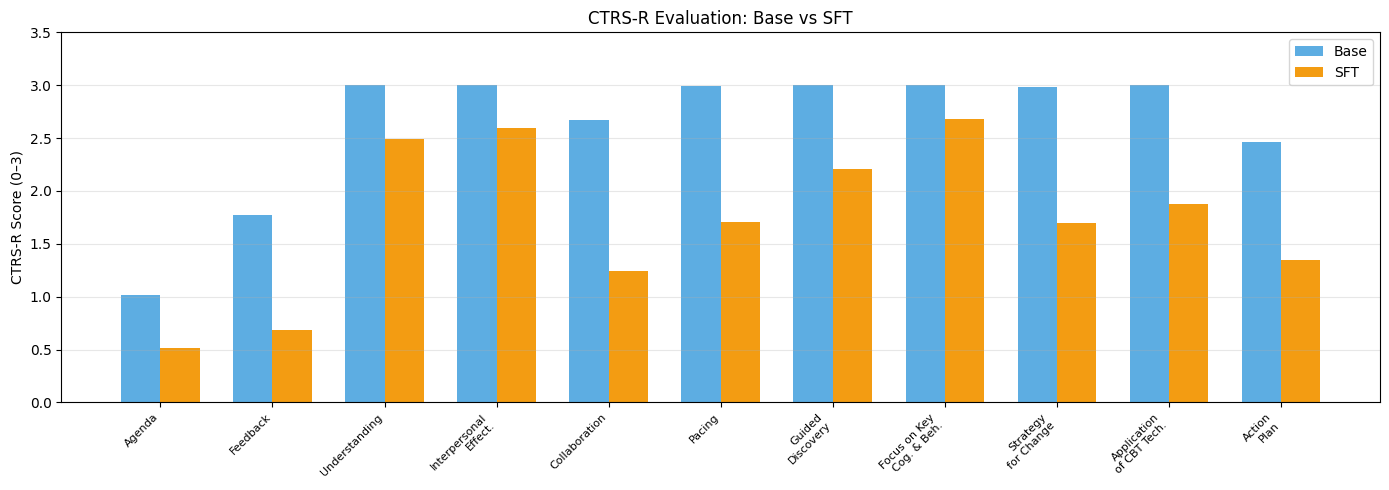

Chart saved → ../reports/ctsr_eval_chart.png


In [11]:
base_means = scores_df[scores_df["model"] == "base"][ITEM_KEYS].mean()
sft_means  = scores_df[scores_df["model"] == "sft"][ITEM_KEYS].mean()

x = np.arange(len(ITEM_KEYS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width / 2, base_means.values, width, label="Base", color="#5dade2")
ax.bar(x + width / 2, sft_means.values,  width, label="SFT",  color="#f39c12")

ax.set_ylabel("CTRS-R Score (0–3)")
ax.set_title("CTRS-R Evaluation: Base vs SFT")
ax.set_xticks(x)
ax.set_xticklabels(ITEM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 3.5)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(CHART_PNG, dpi=150)
plt.show()
print(f"Chart saved → {CHART_PNG}")